# Custom Video Anomaly Detection (MULDE or STG-NF)

Run anomaly detection on a custom `.mp4` video with **either** of two complementary models:

- **MULDE** (Multiscale Log-Density Estimation) — detects **appearance anomalies** using Hiera-L features + a multiscale score-matching network. Needs only the video file.
- **STG-NF** (Spatio-Temporal Graph Normalizing Flows) — detects **motion/pose anomalies** using body-keypoint sequences (AlphaPose) + a normalizing-flow model. Needs visible people in the video.

Both models produce per-frame **log-likelihood** scores (higher = more normal) that feed the same visualization pipeline, yielding:

- A **multi-panel anomaly dashboard** (score vs time, per-frame labels, score histogram)
- **Automatic anomaly segments** with start/end times in seconds (FPS-aware)
- Per-frame CSV with `timestamp_sec`, `is_anomaly`, and `classification`

> **Tip:** STG-NF and MULDE catch different anomaly types. For full coverage, run the notebook twice (once per model) on the same video and compare dashboards.

## Step 1: Mount Google Drive
Run the cell below to authenticate and mount your Google Drive to access model checkpoints and save experiments.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Choose Model
Set `MODEL_CHOICE` below to the model you want to run. The subsequent steps automatically install the right dependencies and run the matching inference path.

| Model | What it detects | Input | Setup time |
|-------|-----------------|-------|------------|
| `"MULDE"` | Appearance anomalies (unusual pixels/objects) | Video frames | ~1 min |
| `"STG-NF"` | Motion anomalies (unusual body movement) | Body pose keypoints | ~5 min (AlphaPose) |

In [2]:
# Choose the model: "MULDE" or "STG-NF"
MODEL_CHOICE = "MULDE"

assert MODEL_CHOICE in {"MULDE", "STG-NF"}, f"MODEL_CHOICE must be 'MULDE' or 'STG-NF', got {MODEL_CHOICE!r}"
print(f"Selected model: {MODEL_CHOICE}")

Selected model: MULDE


## Step 3: Install Dependencies
MULDE needs Hiera + timm + decord. STG-NF additionally needs AlphaPose and its pose-estimation dependencies.

In [3]:
# MULDE dependencies (always installed)
!pip install -q timm decord opencv-python-headless pandas tqdm matplotlib joblib scikit-learn scipy
!pip install -q git+https://github.com/facebookresearch/hiera.git@b12b842542ee5c757fcfec8c41f6b56fcbe89b65

# STG-NF / AlphaPose dependencies (only when needed)
if MODEL_CHOICE == "STG-NF":
  !apt-get -qq update
  !apt-get -qq install -y libyaml-dev ffmpeg
  !pip -q install gdown cython git+https://github.com/samson-wang/cython_bbox.git \
      halpecocotools pycocotools munkres natsort easydict yacs pyyaml scipy \
      tensorboardX terminaltables loguru thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 89.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Step 4: Clone Repositories
Clone the PRISM repository (always, for `mulde_visualization.py` and `run_mulde_on_custom_video.py`). When using STG-NF, also clone the STG-NF repo, build AlphaPose, and download its pretrained weights.

In [4]:
import os, re, sys, time, subprocess
from pathlib import Path

# --- PRISM repo (always — provides visualization.py) ---
REPO_DIR = "/content/PRISM"
if not os.path.exists(REPO_DIR):
  !git clone https://github.com/Hadi6618/PRISM.git {REPO_DIR}
else:
  %cd {REPO_DIR}
  !git pull
%cd {REPO_DIR}

# --- MULDE repo (provides MULDE_test.py; only needed for MULDE inference) ---
MULDE_REPO_DIR = "/content/MULDE"
if not os.path.exists(MULDE_REPO_DIR):
  subprocess.run(["git", "clone", "https://github.com/Hadi6618/MULDE.git", MULDE_REPO_DIR], check=True)
else:
  subprocess.run(["git", "-C", MULDE_REPO_DIR, "pull"], check=True)
print("MULDE repo at", MULDE_REPO_DIR)

# Make PRISM importable (visualization.py) for any subprocess or notebook cell.
if REPO_DIR not in sys.path:
  sys.path.insert(0, REPO_DIR)

# Sanity check: visualization.py must be importable now.
from visualization import build_results_dataframe  # noqa: F401
print("visualization.py loaded from PRISM repo.")

# --- STG-NF + AlphaPose (only when needed) ---
if MODEL_CHOICE == "STG-NF":
  STGNF_REPO_DIR = "/content/STG-NF"
  ALPHAPOSE_DIR = Path("/content/AlphaPose")
  ALPHAPOSE_COMMIT = "c60106d19afb443e964df6f06ed1842962f5f1f7"

  if not os.path.exists(STGNF_REPO_DIR):
    subprocess.run(["git", "clone", "https://github.com/Hadi6618/STG-NF.git", STGNF_REPO_DIR], check=True)
  print("STG-NF repo at", STGNF_REPO_DIR)

  if not ALPHAPOSE_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/MVIG-SJTU/AlphaPose.git", str(ALPHAPOSE_DIR)], check=True)
  if ALPHAPOSE_COMMIT:
    subprocess.run(["git", "fetch", "--all", "--tags"], cwd=ALPHAPOSE_DIR, check=True)
    subprocess.run(["git", "checkout", ALPHAPOSE_COMMIT], cwd=ALPHAPOSE_DIR, check=True)

  # Compatibility patch for current NumPy (np.float / np.int / np.bool were removed)
  for py_file in ALPHAPOSE_DIR.rglob("*.py"):
    text = py_file.read_text(errors="ignore")
    if "np.float" in text or "np.int" in text or "np.bool" in text:
      text = re.sub(r"np\.float(?!\d)", "float", text)
      text = re.sub(r"np\.int(?!\d)", "int", text)
      text = re.sub(r"np\.bool(?!\w)", "bool", text)
      py_file.write_text(text)

  build_marker = ALPHAPOSE_DIR / ".build_develop_done"
  if not build_marker.exists():
    subprocess.run([sys.executable, "setup.py", "build", "develop", "--user"], cwd=ALPHAPOSE_DIR, check=True)
    build_marker.write_text(time.strftime("%Y-%m-%d %H:%M:%S"))
  else:
    print("AlphaPose build already done")
  print("AlphaPose ready at", ALPHAPOSE_DIR)

  # STG-NF repo compatibility patches (idempotent)
  def replace_if_present(repo_dir, rel_path, old, new):
    p = Path(repo_dir) / rel_path
    text = p.read_text()
    if old in text:
      p.write_text(text.replace(old, new))
      print("patched", rel_path)
    else:
      print("already ok", rel_path)

  # STG-NF repo compatibility patches (idempotent)
  for py_file in Path(STGNF_REPO_DIR).rglob("*.py"):
    text = py_file.read_text(errors="ignore")
    modified_text = text
    if "np.float" in text or "np.int" in text or "np.bool" in text:
      modified_text = re.sub(r"np\.float(?!\d)", "float", modified_text)
      modified_text = re.sub(r"np\.int(?!\d)", "int", modified_text)
      modified_text = re.sub(r"np\.bool(?!\w)", "bool", modified_text)
    if "label=torch.ones(data[0].shape[0])" in modified_text:
      modified_text = modified_text.replace("label=torch.ones(data[0].shape[0])", "label=torch.ones(data[0].shape[0], device=self.args.device)")
    if modified_text != text:
      py_file.write_text(modified_text)


  # Download AlphaPose weights
  import gdown
  def resolve_tracker_weight_path():
    cfg_path = ALPHAPOSE_DIR / "trackers/tracker_cfg.py"
    fallback = ALPHAPOSE_DIR / "trackers/weights/osnet_x0_25_msmt17.pt"
    if not cfg_path.exists():
      return fallback
    text = cfg_path.read_text(errors="ignore")
    matches = re.findall(r"loadmodel\s*=\s*['\"]([^'\"]+)['\"]", text)
    if not matches:
      return fallback
    configured = matches[-1]
    configured = configured[2:] if configured.startswith("./") else configured
    configured_path = Path(configured)
    return configured_path if configured_path.is_absolute() else ALPHAPOSE_DIR / configured_path

  POSE_CKPT   = ALPHAPOSE_DIR / "pretrained_models/fast_421_res152_256x192.pth"
  YOLO_WEIGHTS= ALPHAPOSE_DIR / "detector/yolo/data/yolov3-spp.weights"
  YOLOX_WEIGHTS = ALPHAPOSE_DIR / "detector/yolox/data/yolox_x.pth"
  REID_WEIGHTS  = resolve_tracker_weight_path()

  def dl(file_id, target):
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    if not (target.exists() and target.stat().st_size > 0):
      gdown.download(id=file_id, output=str(target), quiet=False)
    return target

  dl("1kfyedqyn8exjbbNmYq8XGd2EooQjPtF9", POSE_CKPT)
  dl("1D47msNOOiJKvPOXlnpyzdKA3k6E97NTC", YOLO_WEIGHTS)
  dl("1myNKfr2cXqiHZVXaaG8ZAq_U2UpeOLfG", REID_WEIGHTS)

  YOLOX_WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
  if not (YOLOX_WEIGHTS.exists() and YOLOX_WEIGHTS.stat().st_size > 0):
    subprocess.run(["wget", "-O", str(YOLOX_WEIGHTS),
                    "https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_x.pth"], check=True)
  print("All AlphaPose weights are present.")


Cloning into '/content/PRISM'...
remote: Enumerating objects: 317, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 317 (delta 32), reused 52 (delta 14), pack-reused 241 (from 1)
Receiving objects: 100% (317/317), 3.66 MiB | 11.47 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/PRISM
MULDE repo at /content/MULDE
visualization.py loaded from PRISM repo.


## Step 5: Configure Paths and Parameters
Set the paths for the model you chose. Threshold/segment parameters are shared by both models.

In [ ]:
ARCHIVE_PATH = Path("/content/drive/MyDrive/Avenue_Dataset.zip")
EXTRACT_ROOT = Path("/content/avenue_dataset")
!unzip -q "{ARCHIVE_PATH}" -d "{EXTRACT_ROOT}"

In [5]:
# ======================== MULDE CONFIG ========================
# Used only when MODEL_CHOICE == "MULDE"
# Shanghai example (commented) and Avenue example (active) are shown.
"""
# ShanghaiTech:
VIDEO_PATH        = "/content/drive/MyDrive/Experiments/Videos/8.mp4"
CHECKPOINT_PATH   = "/content/drive/MyDrive/MULDE/runs/shanghaitech_hiera_l_mulde/2026_06_10_04_51_41/checkpoints/mulde_final.pt"
STATS_PATH        = "/content/drive/MyDrive/MULDE/features/hiera_large_16x224_mae_k400_ft_k400_centered_s4/train_feature_stats.npz"
GMM_PATH          = "/content/drive/MyDrive/MULDE/runs/shanghaitech_hiera_l_mulde/2026_06_10_04_51_41/artifacts/gmm_components_5.joblib"
OUTPUT_DIR        = "/content/drive/MyDrive/Experiments"
"""


# Avenue:
VIDEO_PATH      = "/content/drive/MyDrive/Experiments/Videos/8.mp4"
CHECKPOINT_PATH = "/content/drive/MyDrive/MULDE/runs/avenue_hiera_l_mulde/Final_avenue_scores/checkpoints/mulde_final.pt"
STATS_PATH      = "/content/drive/MyDrive/MULDE/features/avenue_features/train_feature_stats.npz"
GMM_PATH        = "/content/drive/MyDrive/MULDE/runs/avenue_hiera_l_mulde/Final_avenue_scores/artifacts/gmm_components_5.joblib"
OUTPUT_DIR      = "/content/drive/MyDrive/Experiments"


'''
# ======================== STG-NF CONFIG ========================
# Used only when MODEL_CHOICE == "STG-NF"
STGNF_VIDEO_PATH = "/content/avenue_dataset/Avenue Dataset/testing_videos/01.avi"

# Pretrained checkpoint on Drive. Alternatively use the bundled repo checkpoint:
#   "/content/STG-NF/checkpoints/ShanghaiTech_85_9.tar"  (ShanghaiTech, 85.9% AUC)
STGNF_CHECKPOINT   = "/content/drive/MyDrive/STG-NF/Avenue_dataset/logs/Avenue/Avenue_57/Avenue_57.tar"
STGNF_OUTPUT_DIR   = "/content/drive/MyDrive/Experiments"
STGNF_DATASET      = "Avenue"   # must match the checkpoint's training dataset
STGNF_SEG_LEN      = 24               # sliding-window length (must match training)
STGNF_SMOOTH_SIGMA = 7.0              # temporal Gaussian smoothing sigma
STGNF_ATTENTION    = "dual"           # none|skeleton|frame|dual|triplet (must match training)

'''

# ======================== SHARED THRESHOLD / SEGMENT TUNING ========================
THRESHOLD_METHOD     = "mad"        # mad | percentile | manual
THRESHOLD_MAD_K      = 3.0          # used when THRESHOLD_METHOD = mad
THRESHOLD_PERCENTILE = 90.0         # used when THRESHOLD_METHOD = percentile
MANUAL_THRESHOLD     = None         # set a float when THRESHOLD_METHOD = manual
MIN_SEGMENT_SEC      = 0.4          # ignore shorter anomaly bursts
MERGE_GAP_SEC        = 0.25         # merge segments closer than this gap

# Optional: highlight known ground-truth frame ranges in yellow (e.g. "120-180")
KNOWN_ANOMALY_RANGES = None

print(f"Configuration ready for {MODEL_CHOICE}.")

Configuration ready for MULDE.


## Step 6a: Run MULDE Inference
Runs only when `MODEL_CHOICE == "MULDE"`. Extracts Hiera-L features, computes multiscale log-density signatures, scores them with the GMM, and produces the dashboard + CSV artifacts.

In [7]:
assert MODEL_CHOICE == 'MULDE', f"This cell is for MULDE. Set MODEL_CHOICE = 'MULDE' in Step 2 (got {MODEL_CHOICE!r})."

# MULDE_test.py lives in the MULDE repo and imports visualization.py from the PRISM repo.
# Set PYTHONPATH so the subprocess can resolve visualization, then run from the MULDE dir.
mulde_script = "/content/MULDE/MULDE_test.py"
assert os.path.exists(mulde_script), f"MULDE_test.py not found at {mulde_script}. Did Step 4 clone the MULDE repo?"

env = os.environ.copy()
env["PYTHONPATH"] = REPO_DIR + os.pathsep + env.get("PYTHONPATH", "")

# Construct the command list to avoid string quoting/continuation issues
cmd_parts = [
    "python", f"'{mulde_script}'",
    "--video", f"'{VIDEO_PATH}'",
    "--checkpoint", f"'{CHECKPOINT_PATH}'",
    "--stats", f"'{STATS_PATH}'",
    "--gmm", f"'{GMM_PATH}'",
    "--output_dir", f"'{OUTPUT_DIR}'",
    "--smooth_sigma", "10.0",
    "--threshold_method", str(THRESHOLD_METHOD),
    "--threshold_mad_k", str(THRESHOLD_MAD_K),
    "--threshold_percentile", str(THRESHOLD_PERCENTILE),
    "--min_segment_sec", str(MIN_SEGMENT_SEC),
    "--merge_gap_sec", str(MERGE_GAP_SEC)
]

if MANUAL_THRESHOLD is not None:
    cmd_parts.extend(["--threshold", str(MANUAL_THRESHOLD)])
if KNOWN_ANOMALY_RANGES:
    cmd_parts.extend(["--shading", f"'{KNOWN_ANOMALY_RANGES}'"])

cmd = " ".join(cmd_parts)

# Run with the augmented PYTHONPATH (visualization.py resolvable) from the MULDE repo.
os.environ.update(env)
%cd /content/MULDE
!{cmd}
%cd /content/PRISM

/content/MULDE
Cloning into '/content/MULDE_official'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 21 (delta 6), reused 5 (delta 5), pack-reused 11 (from 1)
Receiving objects: 100% (21/21), 16.03 KiB | 1.23 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Loading Hiera-L model (hiera_large_16x224, checkpoint=mae_k400_ft_k400) from PyTorch Hub...
Downloading: "https://github.com/facebookresearch/hiera/zipball/main" to /root/.cache/torch/hub/main.zip
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Downloading: "https://dl.fbaipublicfiles.com/hiera/hiera_large_16x224.pth" to /root/.cache/torch/hub/checkpoints/hiera_large_16x224.pth
100% 2.38G/2.38G [01:06<00:00, 3

## Step 6b: Run STG-NF Inference
Runs only when `MODEL_CHOICE == "STG-NF"`. Two cells:

1. **Pose extraction** — AlphaPose (YOLOX + FastPose + ReID tracking) extracts body keypoints from the video and converts them to the STG-NF tracked-person JSON format.
2. **Model inference + scoring** — loads the STG-NF checkpoint, runs the normalizing-flow model on the pose segments, maps per-segment scores back to per-frame log-likelihoods, and produces the same dashboard + CSV artifacts as MULDE.

> **Note:** STG-NF requires visible human bodies. A video with no detected people will produce no scores.

In [ ]:
assert MODEL_CHOICE == "STG-NF", f"This cell is for STG-NF. Set MODEL_CHOICE = 'STG-NF' in Step 2 (got {MODEL_CHOICE!r})."

import os, sys, json, shutil, subprocess
from pathlib import Path

STGNF_REPO_DIR = "/content/STG-NF"
ALPHAPOSE_DIR  = "/content/AlphaPose"
POSE_WORK_DIR  = Path("/content/stgnf_pose_work")
POSE_WORK_DIR.mkdir(parents=True, exist_ok=True)

video_path = STGNF_VIDEO_PATH
video_stem = Path(video_path).stem
local_out  = POSE_WORK_DIR / video_stem
if local_out.exists():
    shutil.rmtree(local_out)
local_out.mkdir(parents=True, exist_ok=True)

cfg_path = str(Path(ALPHAPOSE_DIR) / "configs/coco/resnet/256x192_res152_lr1e-3_1x-duc.yaml")
ckpt_path = str(Path(ALPHAPOSE_DIR) / "pretrained_models/fast_421_res152_256x192.pth")

cmd = [
    sys.executable, "scripts/demo_inference.py",
    "--cfg", cfg_path,
    "--checkpoint", ckpt_path,
    "--outdir", str(local_out),
    "--detector", "yolox-x",
    "--indir" if os.path.isdir(video_path) else "--video", str(video_path),
    "--sp", "--pose_track",
    "--detbatch", "1", "--posebatch", "32", "--qsize", "10",
]
print("$ " + " ".join(cmd))
# Stream stdout line-by-line so the output buffer never fills up
# (subprocess.run can deadlock when AlphaPose floods stdout).
import time as _time
process = subprocess.Popen(
    cmd, cwd=ALPHAPOSE_DIR,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
try:
    while True:
        line = process.stdout.readline()
        if line:
            print(line, end="")
        elif process.poll() is not None:
            break
        else:
            _time.sleep(0.1)
    if process.returncode != 0:
        raise subprocess.CalledProcessError(process.returncode, cmd)
finally:
    if process.poll() is None:
        process.kill()

raw_json = local_out / "alphapose-results.json"
assert raw_json.exists() and raw_json.stat().st_size > 0, \
    f"AlphaPose produced no output: {raw_json}. The video may contain no people."

# Convert raw AlphaPose results to STG-NF tracked-person format
sys.path.insert(0, STGNF_REPO_DIR)
from gen_data import convert_data_format

with open(raw_json, "r") as f:
    raw_data = json.load(f)
tracked = convert_data_format(raw_data, split="None")

# STG-NF dataset loader parses filenames as "{scene}_{clip}_alphapose_tracked_person.json"
tracked_path = local_out / "01_0001_alphapose_tracked_person.json"
with open(tracked_path, "w") as f:
    json.dump(tracked, f)

shutil.rmtree(local_out / "poseflow", ignore_errors=True)
print(f"Pose extraction complete: {len(tracked)} person track(s) -> {tracked_path}")


In [ ]:
assert MODEL_CHOICE == "STG-NF", f"This cell is for STG-NF. Set MODEL_CHOICE = 'STG-NF' in Step 2 (got {MODEL_CHOICE!r})."

import os, sys, json
from pathlib import Path
import numpy as np
import torch
import cv2
from scipy.ndimage import gaussian_filter1d

STGNF_REPO_DIR = "/content/STG-NF"
os.chdir(STGNF_REPO_DIR)
sys.path.insert(0, STGNF_REPO_DIR)

# Defensively reload STG-NF modules so re-runs pick up the cwd above.
for name in list(sys.modules):
    if name in ("dataset", "args", "gen_data") or name.startswith("utils") or name.startswith("models"):
        del sys.modules[name]

from args import init_parser, init_sub_args
from dataset import get_dataset_and_loader
from models.STG_NF.model_pose import STG_NF
from models.training import Trainer
from utils.data_utils import trans_list
from utils.optim_init import init_optimizer, init_scheduler
from utils.train_utils import init_model_params

POSE_WORK_DIR = Path("/content/stgnf_pose_work")
video_path = STGNF_VIDEO_PATH
video_stem = Path(video_path).stem
pose_dir  = str(POSE_WORK_DIR / video_stem)

# Frame count + FPS from the actual video or image directory
if os.path.isdir(video_path):
    from visualization import detect_fps_for_image_dir
    img_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp')
    img_files = sorted([f for f in os.listdir(video_path) if f.lower().endswith(img_extensions)])
    num_frames = len(img_files)
    fps = detect_fps_for_image_dir(video_path)
    print(f"Image Directory: {num_frames} frames @ {fps:.2f} FPS")
else:
    cap = cv2.VideoCapture(video_path)
    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps <= 0:
        fps = 25.0
    print(f"Video: {num_frames} frames @ {fps:.2f} FPS")

argv = [
    "--dataset", STGNF_DATASET,
    "--pose_path_test", pose_dir,
    "--pose_path_train", pose_dir,   # unused in only_test mode but required by init_sub_args
    "--vid_path_test", str(Path(video_path).parent),
    "--vid_path_train", str(Path(video_path).parent),
    "--checkpoint", STGNF_CHECKPOINT,
    "--seg_len", str(STGNF_SEG_LEN),
    "--batch_size", "256",
    "--num_workers", "2",
    "--device", "cuda:0" if torch.cuda.is_available() else "cpu",
]
if STGNF_ATTENTION != "none":
    argv += ["--attention", STGNF_ATTENTION]

args = init_parser().parse_args(argv)
args, _ = init_sub_args(args)

dataset, loader = get_dataset_and_loader(args, trans_list=trans_list, only_test=True)
model_args = init_model_params(args, dataset)
model = STG_NF(**model_args)
trainer = Trainer(
    args, model, loader["train"], loader["test"],
    optimizer_f=init_optimizer(args.model_optimizer, lr=args.model_lr),
    scheduler_f=init_scheduler(args.model_sched, lr=args.model_lr, epochs=args.epochs),
)
trainer.load_checkpoint(STGNF_CHECKPOINT)
normality_scores = trainer.test()
metadata = dataset["test"].metadata
print(f"Computed {len(normality_scores)} segment scores across {len(metadata)} pose segments.")


def map_scores_to_frames(scores, meta, n_frames, seg_len):
    """Map per-segment normality scores to per-frame log-likelihood.

    Mirrors scoring_utils.get_clip_score without depending on ground-truth masks:
    each segment score is placed at start_frame + seg_len//2, unmapped frames get
    the finite-max (most-normal) value, and we take the min across persons so that
    any anomalous person flags the frame.
    """
    meta_np = np.array(meta)  # rows: [scene, clip, person_id, start_frame]
    if meta_np.size == 0:
        raise ValueError(
            "No pose segments detected -- the video may contain no people. "
            "STG-NF requires visible human bodies."
        )
    person_ids = set(meta_np[:, 2].tolist())
    per_person = {pid: np.full(n_frames, np.inf, dtype=np.float64) for pid in person_ids}
    for pid in person_ids:
        inds = np.where(meta_np[:, 2] == pid)[0]
        frame_inds = meta_np[inds, 3].astype(int) + seg_len // 2
        for score, fidx in zip(scores[inds], frame_inds):
            if 0 <= fidx < n_frames:
                per_person[pid][fidx] = score
    clip_score = np.amin(np.stack(list(per_person.values())), axis=0)
    finite = np.isfinite(clip_score)
    if finite.any():
        clip_score[~finite] = clip_score[finite].max()
    else:
        clip_score[:] = 0.0
    return clip_score.astype(np.float32)


raw_log_likelihood      = map_scores_to_frames(normality_scores, metadata, num_frames, STGNF_SEG_LEN)
smoothed_log_likelihood = gaussian_filter1d(raw_log_likelihood, sigma=STGNF_SMOOTH_SIGMA).astype(np.float32)

# Feed the shared visualization pipeline (same as MULDE).
from visualization import (
    build_results_dataframe,
    generate_anomaly_dashboard,
    save_anomaly_artifacts,
    print_anomaly_report,
    parse_frame_ranges,
)

video_name = video_stem
manual_ranges = parse_frame_ranges(KNOWN_ANOMALY_RANGES)

df_out, threshold, segments = build_results_dataframe(
    raw_log_likelihood,
    smoothed_log_likelihood,
    fps,
    threshold_method=THRESHOLD_METHOD,
    threshold_percentile=THRESHOLD_PERCENTILE,
    threshold_mad_k=THRESHOLD_MAD_K,
    manual_threshold=MANUAL_THRESHOLD,
    min_segment_sec=MIN_SEGMENT_SEC,
    merge_gap_sec=MERGE_GAP_SEC,
)

os.makedirs(STGNF_OUTPUT_DIR, exist_ok=True)
dashboard_path = os.path.join(STGNF_OUTPUT_DIR, f"{video_name}_anomaly_dashboard.png")
generate_anomaly_dashboard(
    df_out,
    segments,
    video_name=video_name,
    fps=fps,
    threshold=threshold,
    output_path=dashboard_path,
    manual_frame_ranges=manual_ranges or None,
    threshold_method=THRESHOLD_METHOD,
    model_name="STG-NF",
)
artifact_paths = save_anomaly_artifacts(
    df_out,
    segments,
    output_dir=STGNF_OUTPUT_DIR,
    video_name=video_name,
    fps=fps,
    threshold=threshold,
    threshold_method=THRESHOLD_METHOD,
    smooth_sigma=STGNF_SMOOTH_SIGMA,
    dashboard_path=Path(dashboard_path),
    model_name="STG-NF",
)
print_anomaly_report(segments, fps, threshold, THRESHOLD_METHOD, model_name="STG-NF")
print(f"\n✓ Saved STG-NF scores CSV:   {artifact_paths['scores_csv']}")
print(f"✓ Saved anomaly intervals:   {artifact_paths['intervals_csv']}")
print(f"✓ Saved summary JSON:        {artifact_paths['summary_json']}")
print(f"✓ Saved anomaly dashboard:   {artifact_paths['dashboard_png']}")


## Step 7: View Dashboard and Anomaly Intervals
Display the multi-panel dashboard, the anomaly-segment table (in seconds), and per-frame classification stats. This cell works for whichever model you ran in Step 6.

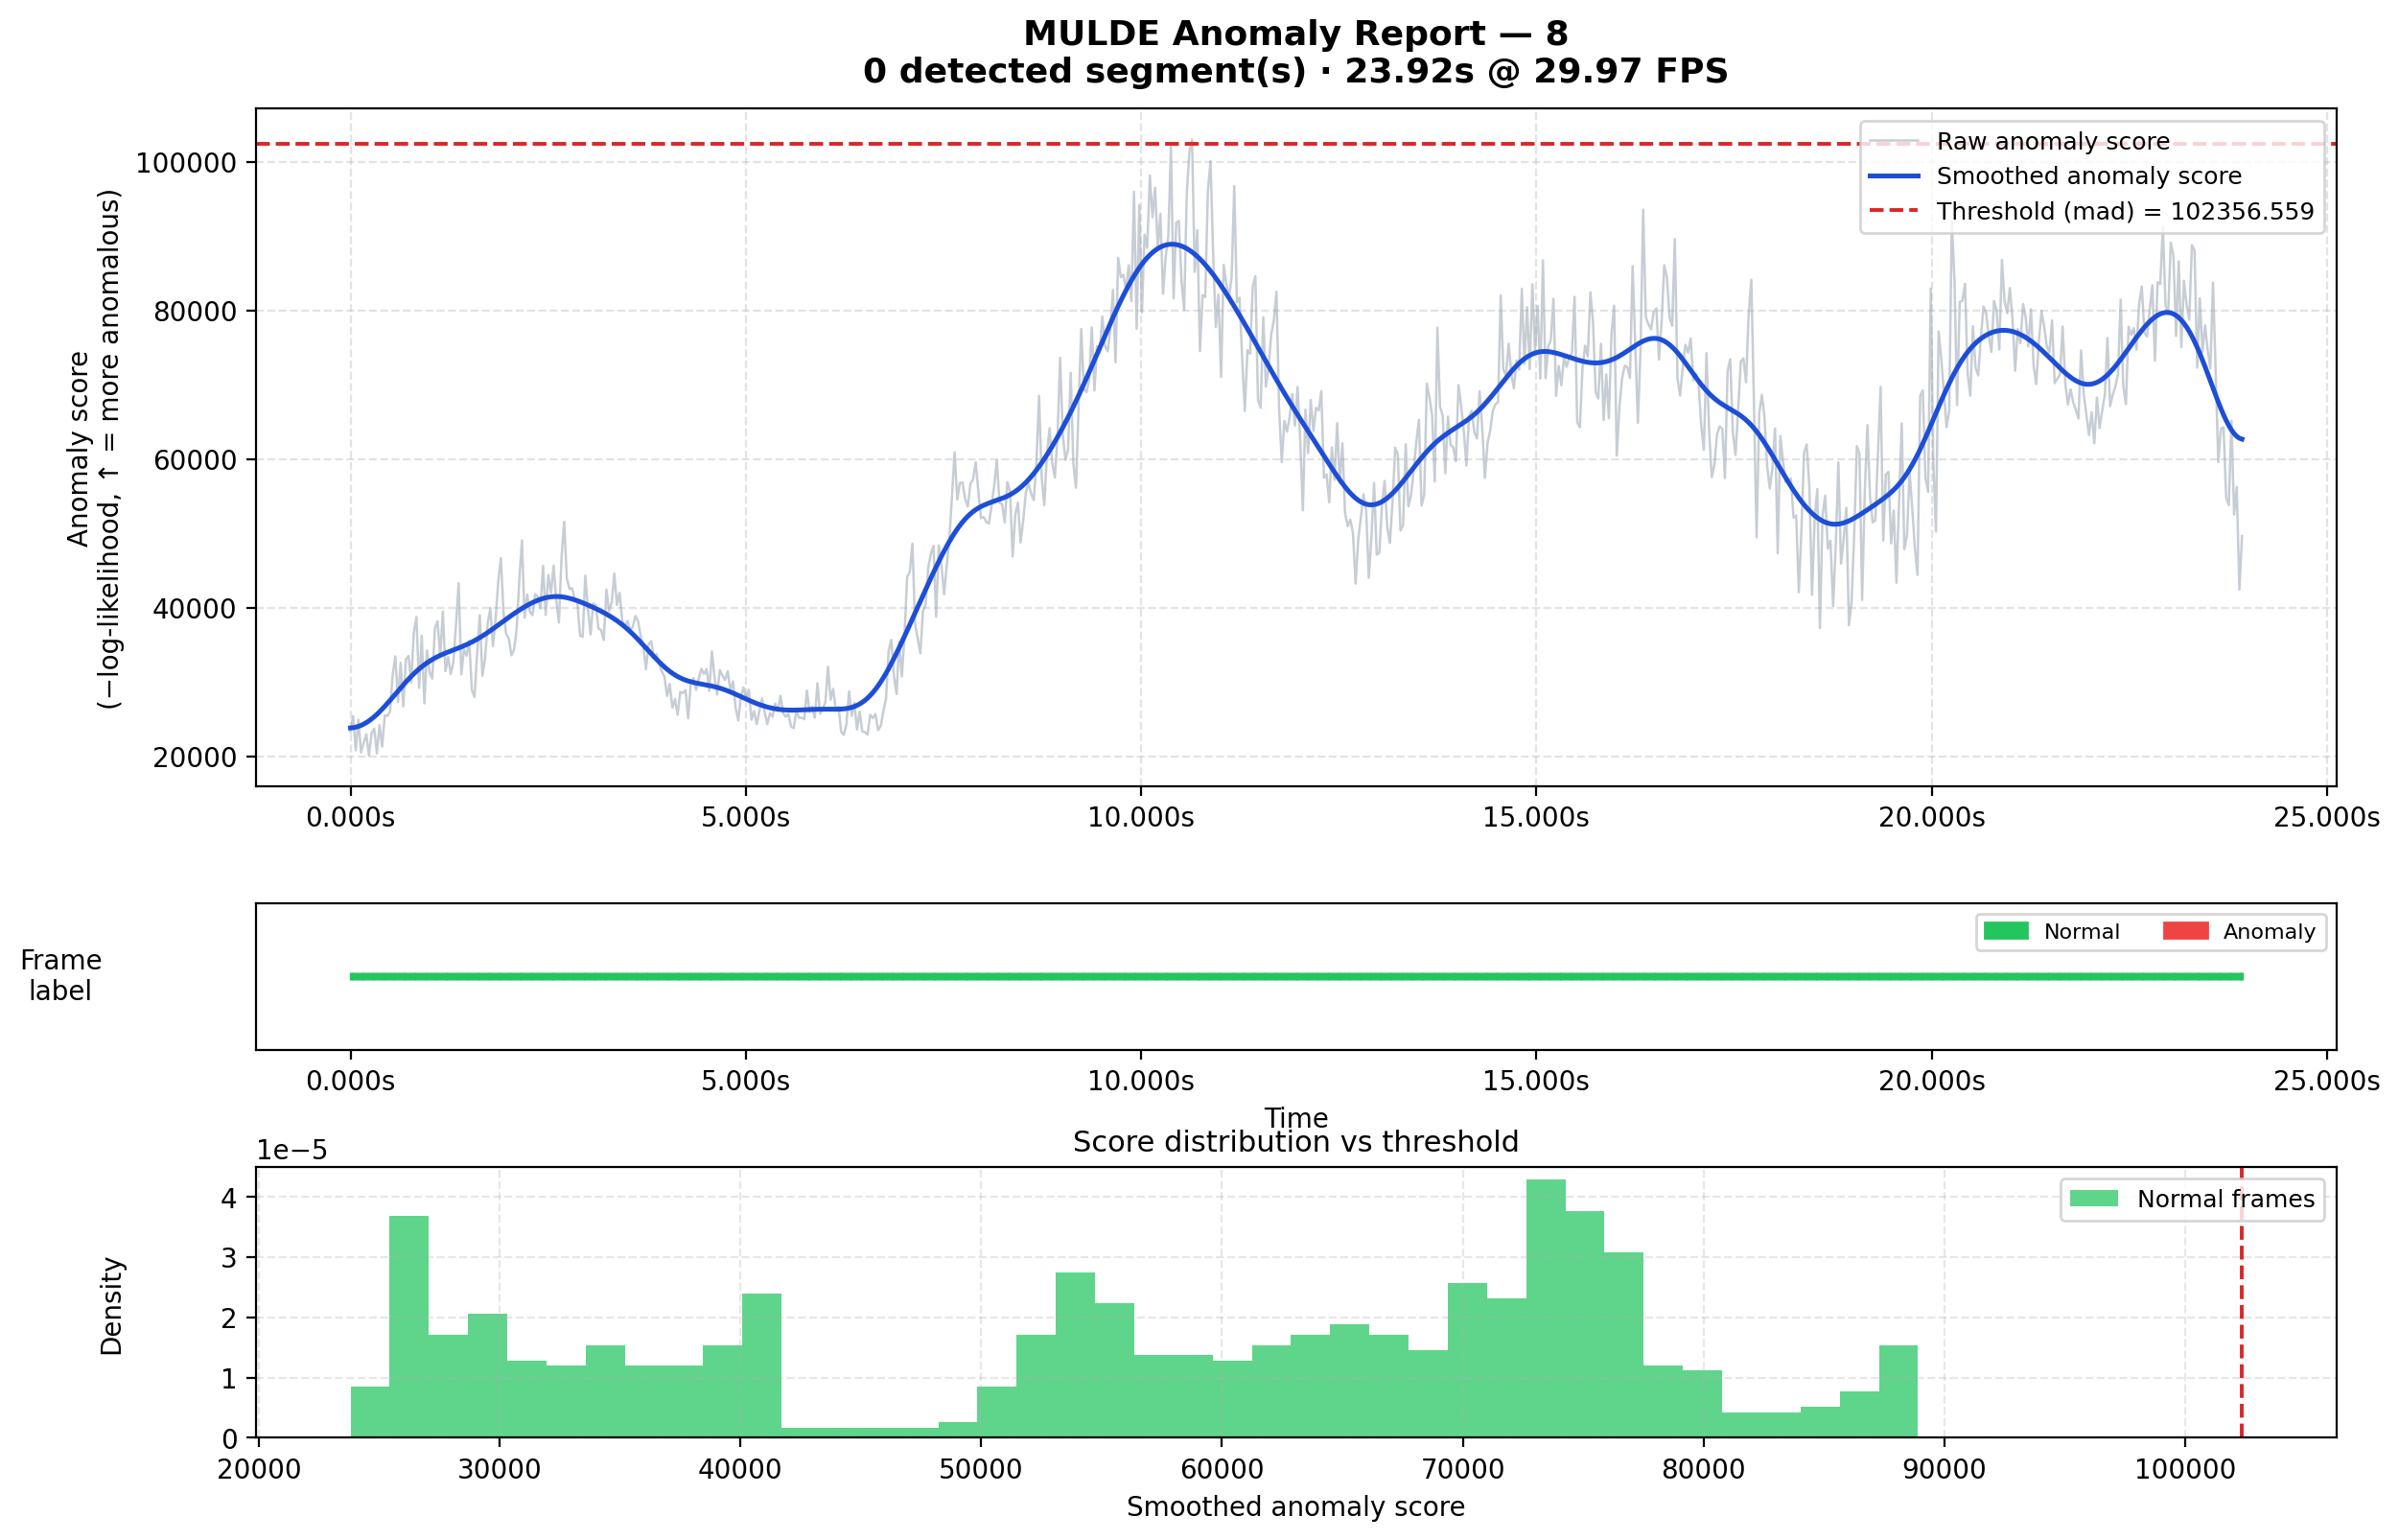


--- Video summary ---
Model:    MULDE
Duration: 23.92s @ 29.97 FPS
Anomaly frames: 0 / 718 (0.0%)
Threshold (mad): 102356.5586
Detected segments: 0

--- Detected anomaly intervals (seconds) ---
No anomaly segments detected above threshold.

No frames classified as anomaly in the per-frame CSV.


In [8]:
from IPython.display import Image, display
import json, os
from pathlib import Path
import pandas as pd

# Resolve which model's artifacts to show
if MODEL_CHOICE == "MULDE":
    ACTIVE_VIDEO_PATH = VIDEO_PATH
    ACTIVE_OUTPUT_DIR = OUTPUT_DIR
    SCORES_SUFFIX = "mulde"
else:
    ACTIVE_VIDEO_PATH = STGNF_VIDEO_PATH
    ACTIVE_OUTPUT_DIR = STGNF_OUTPUT_DIR
    SCORES_SUFFIX = "stgnf"

video_name     = Path(ACTIVE_VIDEO_PATH).stem
dashboard_file = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_anomaly_dashboard.png")
intervals_file = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_anomaly_intervals.csv")
summary_file   = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_anomaly_summary.json")
scores_file    = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_{SCORES_SUFFIX}_scores.csv")

if os.path.exists(dashboard_file):
    display(Image(filename=dashboard_file, width=960))
else:
    print(f"Dashboard not found at: {dashboard_file}. Check output logs above for errors.")

if os.path.exists(summary_file):
    with open(summary_file, "r", encoding="utf-8") as f:
        summary = json.load(f)
    print("\n--- Video summary ---")
    print(f"Model:    {summary.get('model_name', MODEL_CHOICE)}")
    print(f"Duration: {summary['duration_sec']:.2f}s @ {summary['fps']:.2f} FPS")
    print(f"Anomaly frames: {summary['num_anomaly_frames']} / {summary['num_frames']} ({100 * summary['anomaly_frame_ratio']:.1f}%)")
    print(f"Threshold ({summary['threshold_method']}): {summary['anomaly_threshold']:.4f}")
    print(f"Detected segments: {summary['num_anomaly_segments']}")

if os.path.exists(intervals_file):
    intervals_df = pd.read_csv(intervals_file)
    print("\n--- Detected anomaly intervals (seconds) ---")
    if intervals_df.empty:
        print("No anomaly segments detected above threshold.")
    else:
        display(
            intervals_df[
                ["segment_id", "start_frame", "end_frame",
                 "start_sec", "end_sec", "duration_sec",
                 "start_time", "end_time", "time_range"]
            ]
        )
        print("\nHuman-readable ranges:")
        for _, row in intervals_df.iterrows():
            print(
                f"  Segment {int(row['segment_id'])}: "
                f"{row['start_sec']:.1f}s -> {row['end_sec']:.1f}s "
                f"({row['duration_sec']:.2f}s, frames {int(row['start_frame'])}-{int(row['end_frame'])})"
            )
else:
    print(f"Intervals file not found: {intervals_file}")

if os.path.exists(scores_file):
    scores_df = pd.read_csv(scores_file)
    preview = scores_df.loc[scores_df["is_anomaly"] == 1, ["frame_index", "timestamp_sec", "timestamp", "anomaly_score", "classification"]]
    if preview.empty:
        print("\nNo frames classified as anomaly in the per-frame CSV.")
    else:
        print(f"\nFirst anomalous frames ({min(len(preview), 10)} shown):")
        display(preview.head(10))

## Step 8: Re-tune Threshold Without Re-running Inference (Optional)
If the automatic threshold is too sensitive or too conservative, adjust the settings below and re-run **only this cell**. It reloads the saved per-frame scores CSV (from whichever model you ran) and regenerates the dashboard and interval table — no model inference needed.

/content/PRISM/visualization.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



MULDE ANOMALY DETECTION SUMMARY
FPS: 29.970  |  Threshold (manual): 45000.0000
Detected segments: 1

ID   Frames         Time range                   Duration  
------------------------------------------------------------
1    222-717        7.407s – 23.924s             16.55s


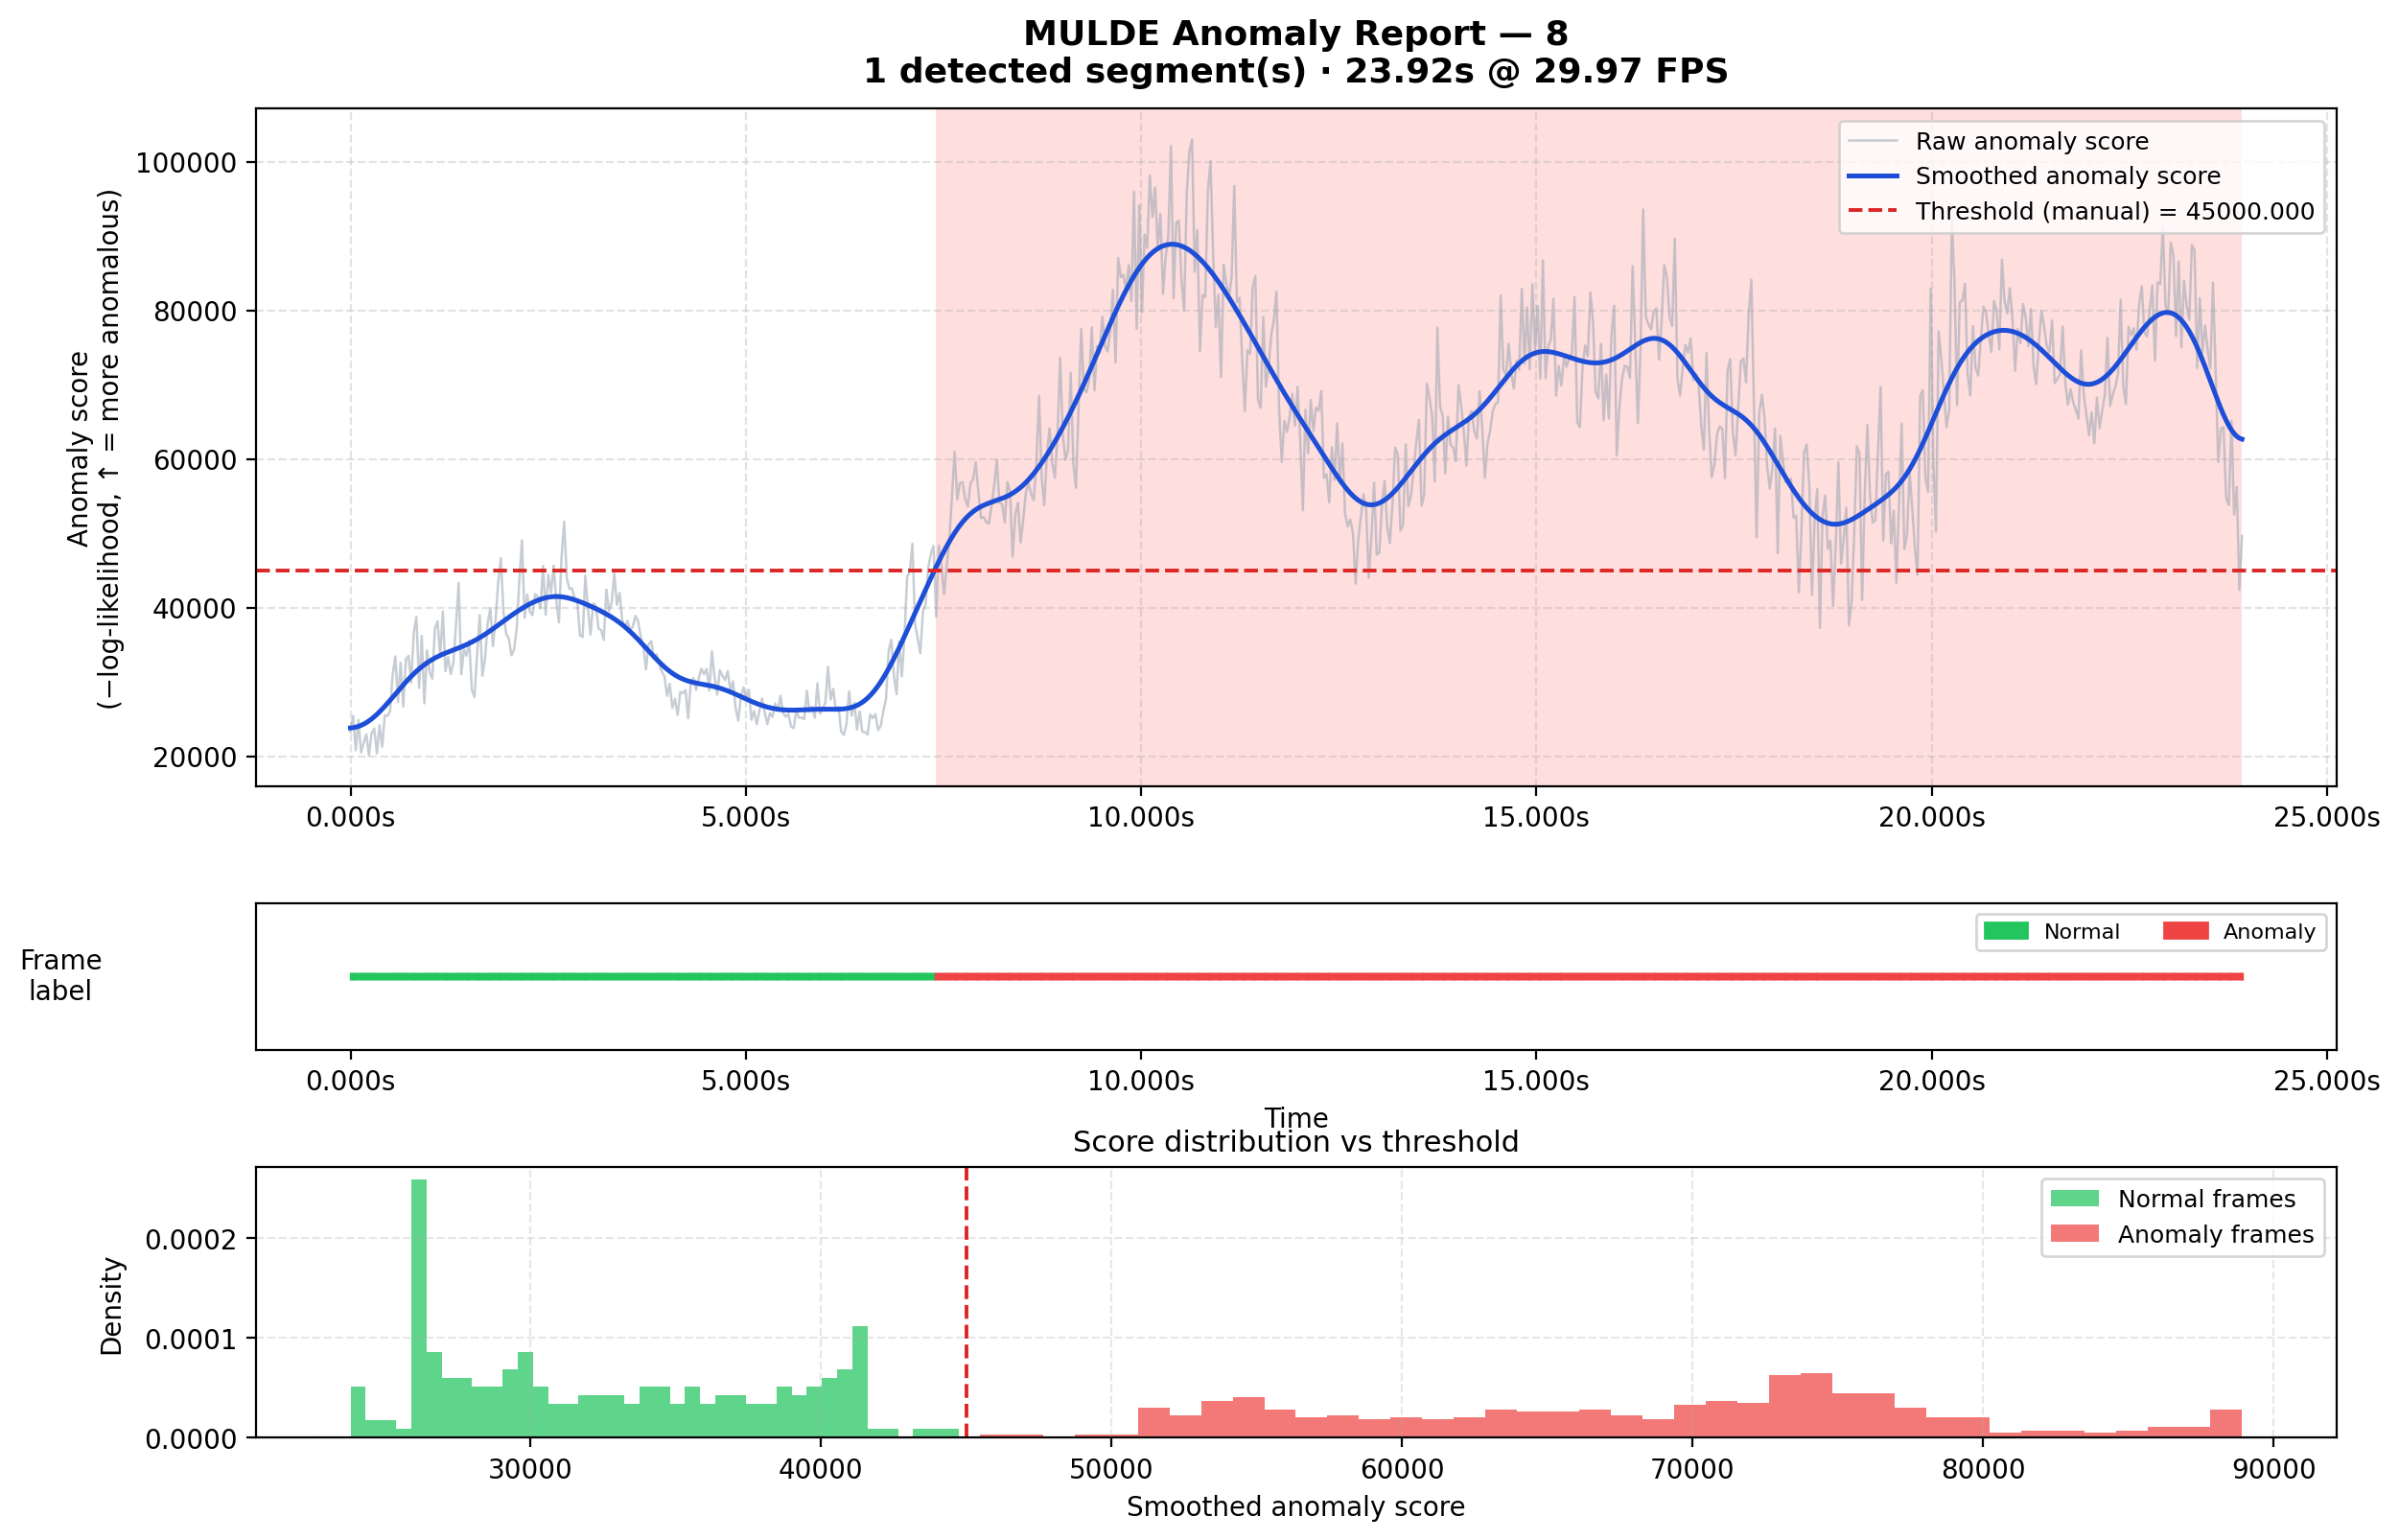

,segment_id,start_sec,end_sec,duration_sec,time_range
0,1,7.407,23.924,16.55,7.407s – 23.924s


In [16]:
import json, os
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

from visualization import (
    build_results_dataframe,
    generate_anomaly_dashboard,
    save_anomaly_artifacts,
    print_anomaly_report,
)

# Resolve which model's saved scores to re-tune
if MODEL_CHOICE == "MULDE":
    ACTIVE_VIDEO_PATH = VIDEO_PATH
    ACTIVE_OUTPUT_DIR = OUTPUT_DIR
    SCORES_SUFFIX = "mulde"
    SMOOTH_SIGMA = 10.0
else:
    ACTIVE_VIDEO_PATH = STGNF_VIDEO_PATH
    ACTIVE_OUTPUT_DIR = STGNF_OUTPUT_DIR
    SCORES_SUFFIX = "stgnf"
    SMOOTH_SIGMA = STGNF_SMOOTH_SIGMA

video_name   = Path(ACTIVE_VIDEO_PATH).stem
scores_file  = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_{SCORES_SUFFIX}_scores.csv")
summary_file = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_anomaly_summary.json")

# --- Tweak these to find the anomalies ---
# If 'mad' is too high, try lowering RETHRESHOLD_MAD_K to 2.0 or 1.5.
# Alternatively, use 'percentile' at 90.0 to see the top 10% most anomalous frames.
RETHRESHOLD_METHOD    = "manual"        # mad | percentile | manual
RETHRESHOLD_MAD_K     = -0.5         # lower = more sensitive (standard is 3.0)
RETHRESHOLD_PERCENTILE= 90.0         # 90.0 means top 10% are anomalies
REMANUAL_THRESHOLD    = 45000
REMIN_SEGMENT_SEC     = 0.3          # lower to catch shorter bursts
REMERGE_GAP_SEC       = 0.3

if not os.path.exists(scores_file):
    raise FileNotFoundError(f"Run Step 6 first. Missing: {scores_file}")

if os.path.exists(summary_file):
    with open(summary_file, "r", encoding="utf-8") as f:
        meta = json.load(f)
    fps = float(meta["fps"])
    smooth_sigma = float(meta.get("smooth_sigma", SMOOTH_SIGMA))
else:
    fps = 25.0
    smooth_sigma = SMOOTH_SIGMA

scores_df = pd.read_csv(scores_file)
df_out, threshold, segments = build_results_dataframe(
    scores_df["raw_log_likelihood"].to_numpy(),
    scores_df["smoothed_log_likelihood"].to_numpy(),
    fps,
    threshold_method=RETHRESHOLD_METHOD,
    threshold_percentile=RETHRESHOLD_PERCENTILE,
    threshold_mad_k=RETHRESHOLD_MAD_K,
    manual_threshold=REMANUAL_THRESHOLD,
    min_segment_sec=REMIN_SEGMENT_SEC,
    merge_gap_sec=REMERGE_GAP_SEC,
)

MODEL_TAG = "MULDE" if MODEL_CHOICE == "MULDE" else "STG-NF"
dashboard_path = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_anomaly_dashboard.png")
generate_anomaly_dashboard(
    df_out,
    segments,
    video_name=video_name,
    fps=fps,
    threshold=threshold,
    output_path=dashboard_path,
    threshold_method=RETHRESHOLD_METHOD,
    model_name=MODEL_TAG,
)
save_anomaly_artifacts(
    df_out,
    segments,
    output_dir=ACTIVE_OUTPUT_DIR,
    video_name=video_name,
    fps=fps,
    threshold=threshold,
    threshold_method=RETHRESHOLD_METHOD,
    smooth_sigma=smooth_sigma,
    dashboard_path=Path(dashboard_path),
    model_name=MODEL_TAG,
)

print_anomaly_report(segments, fps, threshold, RETHRESHOLD_METHOD, model_name=MODEL_TAG)
display(Image(filename=dashboard_path, width=960))

intervals_df = pd.read_csv(os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_anomaly_intervals.csv"))
if not intervals_df.empty:
    display(intervals_df[["segment_id", "start_sec", "end_sec", "duration_sec", "time_range"]])

### Diagnostic Plot: Finding the Right Threshold (MULDE)
Use this plot to see the score levels during the explosion (seconds 7-10) versus the noise (seconds 10-25). Set your `REMANUAL_THRESHOLD` in Step 8 to a value that falls between the 'normal' scores and the 'anomaly' scores shown here.

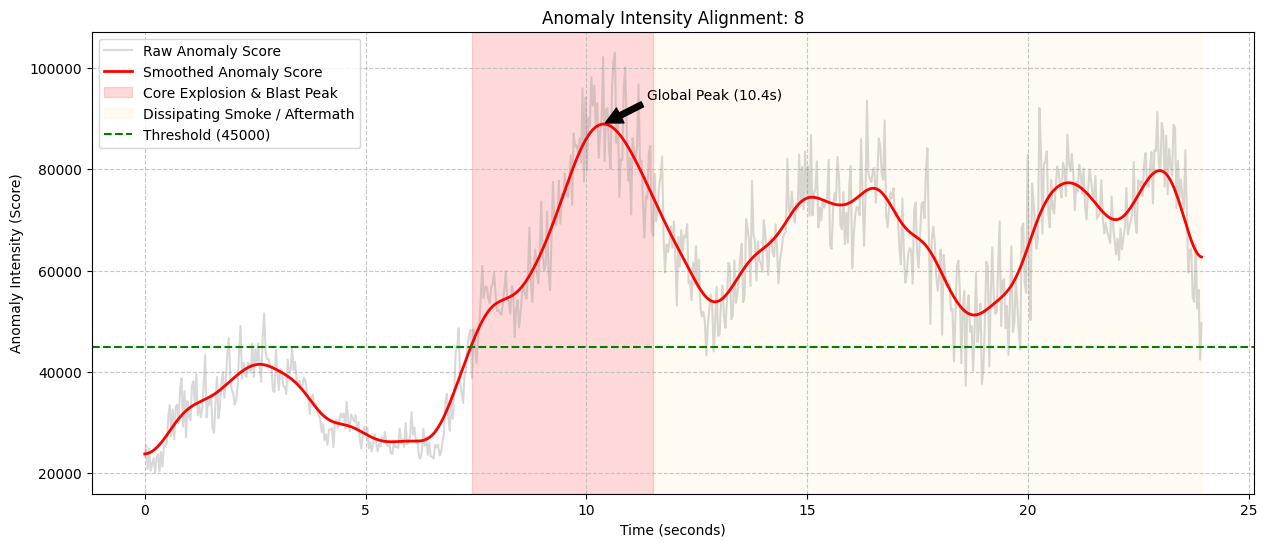

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Multiply by -1 to get Negative Log-Likelihood (Higher = More Anomalous)
raw_inverted = scores_df['raw_log_likelihood'] * -1
smoothed_inverted = scores_df['smoothed_log_likelihood'] * -1

plt.figure(figsize=(15, 6))
plt.plot(scores_df['timestamp_sec'], raw_inverted, label='Raw Anomaly Score', alpha=0.3, color='gray')
plt.plot(scores_df['timestamp_sec'], smoothed_inverted, label='Smoothed Anomaly Score', color='red', linewidth=2)

# Identifying the actual peak in the data for the user
max_idx = smoothed_inverted.idxmax()
max_time = scores_df.loc[max_idx, 'timestamp_sec']
max_val = smoothed_inverted.max()

plt.annotate(f'Global Peak ({max_time:.1f}s)',
             xy=(max_time, max_val),
             xytext=(max_time+1, max_val+5000),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Redefining zones to show that the peak is part of the core explosion event
plt.axvspan(7.4, 11.5, color='red', alpha=0.15, label='Core Explosion & Blast Peak')
plt.axvspan(11.5, 23.9, color='orange', alpha=0.05, label='Dissipating Smoke / Aftermath')

# Threshold as positive value
if 'REMANUAL_THRESHOLD' in globals():
    plt.axhline(y=float(REMANUAL_THRESHOLD), color='green', linestyle='--', label=f'Threshold ({REMANUAL_THRESHOLD})')

plt.title(f'Anomaly Intensity Alignment: {video_name}')
plt.xlabel('Time (seconds)')
plt.ylabel('Anomaly Intensity (Score)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Step 9: Annotated Video with Score Overlay

Build an MP4 that plays the original video with the anomaly score graph
synced below it — a red playhead advances frame-by-frame so you can see
**exactly where** the model flags anomalies with your own eyes.

The annotated video is built from the *current* scores (either the first-run
artifacts from Step 6, or the re-tuned scores from Step 8 if you ran that
cell). Just run this cell after either of those steps.


In [17]:
import os
from pathlib import Path
from visualization import generate_annotated_video

# Use whatever scores are active right now.
# After Step 6:  scores_df / segments are loaded by cell 17 from the CSV.
# After Step 8:  df_out / segments / threshold are fresh from the re-tune.
# We prefer the in-memory re-tune outputs if present, else fall back to the
# scores CSV loaded in cell 17.

if "df_out" in globals():
    ANNOT_DF       = df_out
    ANNOT_SEGMENTS = segments
    ANNOT_THRESH   = threshold
    ANNOT_METHOD   = RETHRESHOLD_METHOD
    ANNOT_FPS      = fps
    ANNOT_MODEL    = MODEL_TAG
else:
    # Fall back to the first-run artifacts (cell 17 variables)
    ANNOT_DF       = scores_df
    # Rebuild segments from the CSV so the overlay matches the dashboard
    from visualization import build_results_dataframe
    summary_file = os.path.join(ACTIVE_OUTPUT_DIR, f"{video_name}_anomaly_summary.json")
    with open(summary_file, "r", encoding="utf-8") as f:
        _meta = json.load(f)
    ANNOT_FPS    = float(_meta["fps"])
    ANNOT_THRESH = float(_meta["anomaly_threshold"])
    ANNOT_METHOD = _meta.get("threshold_method", "mad")
    ANNOT_MODEL  = _meta.get("model_name", "MULDE" if MODEL_CHOICE == "MULDE" else "STG-NF")
    ANNOT_DF, ANNOT_THRESH, ANNOT_SEGMENTS = build_results_dataframe(
        ANNOT_DF["raw_log_likelihood"].to_numpy(),
        ANNOT_DF["smoothed_log_likelihood"].to_numpy(),
        ANNOT_FPS,
        threshold_method=ANNOT_METHOD,
        threshold_mad_k=THRESHOLD_MAD_K if "THRESHOLD_MAD_K" in globals() else 3.0,
    )

annotated_output = os.path.join(
    ACTIVE_OUTPUT_DIR, f"{video_name}_annotated.mp4"
)

print(f"Building annotated video: {Path(ACTIVE_VIDEO_PATH).name}")
print(f"  -> {annotated_output}")
print(f"  ({len(ANNOT_DF)} frames @ {ANNOT_FPS:.2f} FPS)")
print()

annotated_path = generate_annotated_video(
    ACTIVE_VIDEO_PATH,
    ANNOT_DF,
    ANNOT_SEGMENTS,
    output_path=annotated_output,
    fps=ANNOT_FPS,
    threshold=ANNOT_THRESH,
    threshold_method=ANNOT_METHOD,
    model_name=ANNOT_MODEL,
)

size_mb = os.path.getsize(annotated_path) / (1024 * 1024)
print("\nAnnotated video saved (" + f"{size_mb:.1f} MB)")
print(f"Download from: {annotated_path}")


Building annotated video: 8.mp4
  -> /content/drive/MyDrive/Experiments/8_annotated.mp4
  (718 frames @ 29.97 FPS)

  annotated video: 200/721 frames
  annotated video: 400/721 frames
  annotated video: 600/721 frames
  annotated video: 721/721 frames
Saved annotated video: /content/drive/MyDrive/Experiments/8_annotated.mp4

Annotated video saved (14.8 MB)
Download from: /content/drive/MyDrive/Experiments/8_annotated.mp4
